In [1]:
#Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, roc_auc_score, roc_curve

In [2]:
#Loading the dataset
df = pd.read_csv('medical_clean_D209_I.csv')

In [177]:
#Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CaseOrder           10000 non-null  int64  
 1   Customer_id         10000 non-null  object 
 2   Interaction         10000 non-null  object 
 3   UID                 10000 non-null  object 
 4   City                10000 non-null  object 
 5   State               10000 non-null  object 
 6   County              10000 non-null  object 
 7   Zip                 10000 non-null  int64  
 8   Lat                 10000 non-null  float64
 9   Lng                 10000 non-null  float64
 10  Population          10000 non-null  int64  
 11  Area                10000 non-null  object 
 12  TimeZone            10000 non-null  object 
 13  Job                 10000 non-null  object 
 14  Children            10000 non-null  int64  
 15  Age                 10000 non-null  int64  
 16  Incom

In [178]:
#Remove irrelevant columns
df.drop(columns=['CaseOrder', 'Customer_id', 'Interaction', 'UID', 'Lat', 'Lng', 'TimeZone', 'Item1', 'Item2', 'Item3','Item4', 'Item5', 'Item6', 'Item7', 'Item8'], inplace=True)

In [179]:
#Checking for duplicate values
print(df.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool


In [180]:
#Checking for missing values
print(df.isnull().sum())

City                  0
State                 0
County                0
Zip                   0
Population            0
Area                  0
Job                   0
Children              0
Age                   0
Income                0
Marital               0
Gender                0
ReAdmis               0
VitD_levels           0
Doc_visits            0
Full_meals_eaten      0
vitD_supp             0
Soft_drink            0
Initial_admin         0
HighBlood             0
Stroke                0
Complication_risk     0
Overweight            0
Arthritis             0
Diabetes              0
Hyperlipidemia        0
BackPain              0
Anxiety               0
Allergic_rhinitis     0
Reflux_esophagitis    0
Asthma                0
Services              0
Initial_days          0
TotalCharge           0
Additional_charges    0
dtype: int64


In [181]:
#Encode categorical variables using LabelEncoder
label_encoder = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   City                10000 non-null  int32  
 1   State               10000 non-null  int32  
 2   County              10000 non-null  int32  
 3   Zip                 10000 non-null  int64  
 4   Population          10000 non-null  int64  
 5   Area                10000 non-null  int32  
 6   Job                 10000 non-null  int32  
 7   Children            10000 non-null  int64  
 8   Age                 10000 non-null  int64  
 9   Income              10000 non-null  float64
 10  Marital             10000 non-null  int32  
 11  Gender              10000 non-null  int32  
 12  ReAdmis             10000 non-null  int32  
 13  VitD_levels         10000 non-null  float64
 14  Doc_visits          10000 non-null  int64  
 15  Full_meals_eaten    10000 non-null  int64  
 16  vitD_

In [183]:
#Identify outliers based on Z-scores
z_scores = np.abs(zscore(df))
z_score_outliers = (z_scores > 3).sum(axis=0)
print("Outliers based on Z-score method:")
print(z_score_outliers)

Outliers based on Z-score method:
City                    0
State                   0
County                  0
Zip                     0
Population            218
Area                    0
Job                     0
Children              202
Age                     0
Income                143
Marital                 0
Gender                  0
ReAdmis                 0
VitD_levels            24
Doc_visits              8
Full_meals_eaten       33
vitD_supp              70
Soft_drink              0
Initial_admin           0
HighBlood               0
Stroke                  0
Complication_risk       0
Overweight              0
Arthritis               0
Diabetes                0
Hyperlipidemia          0
BackPain                0
Anxiety                 0
Allergic_rhinitis       0
Reflux_esophagitis      0
Asthma                  0
Services                0
Initial_days            0
TotalCharge             0
Additional_charges      0
dtype: int64


<Axes: xlabel='Population'>

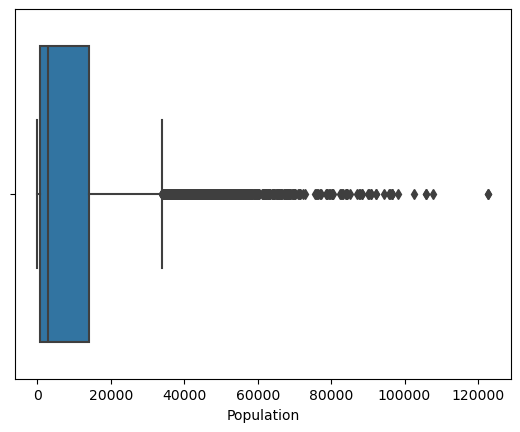

In [184]:
#Checking for outliers for Population
sns.boxplot(x = 'Population', data = df)

<Axes: xlabel='Children'>

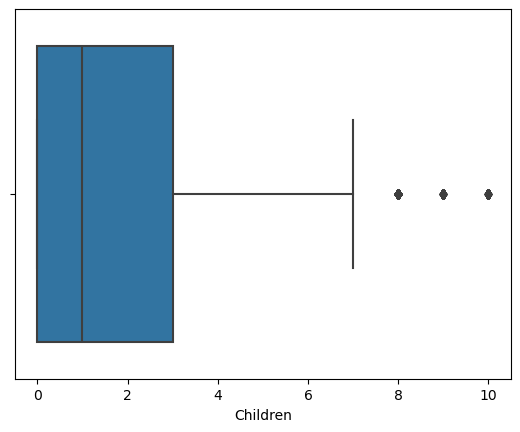

In [185]:
#Checking for outliers for Children
sns.boxplot(x = 'Children', data = df)

<Axes: xlabel='Income'>

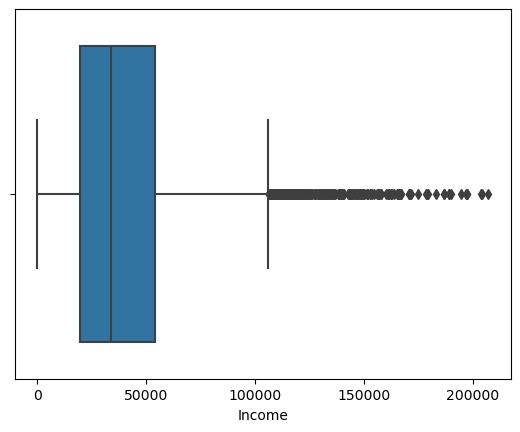

In [186]:
#Checking for outliers for Income
sns.boxplot(x = 'Income', data = df)

<Axes: xlabel='VitD_levels'>

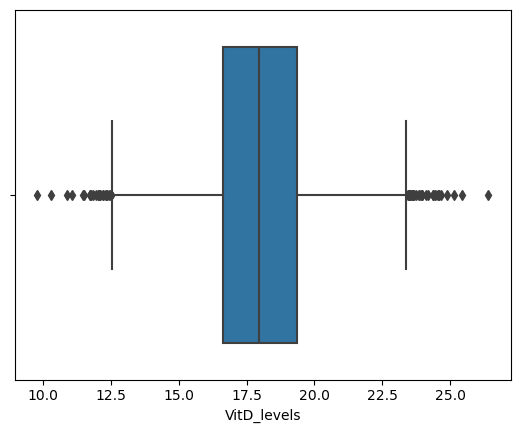

In [187]:
#Checking for outliers for VitD_levels
sns.boxplot(x = 'VitD_levels', data = df)

<Axes: xlabel='Doc_visits'>

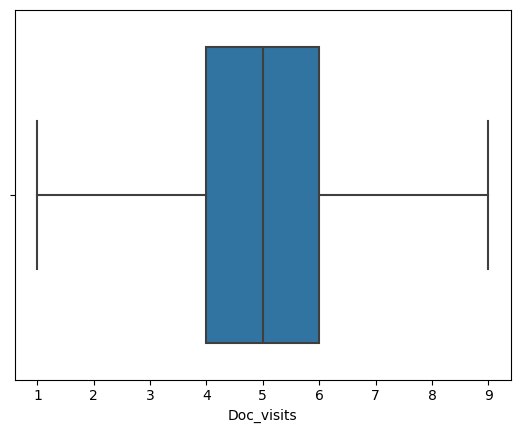

In [188]:
#Checking for outliers for Doc_visits
sns.boxplot(x = 'Doc_visits', data = df)

<Axes: xlabel='Full_meals_eaten'>

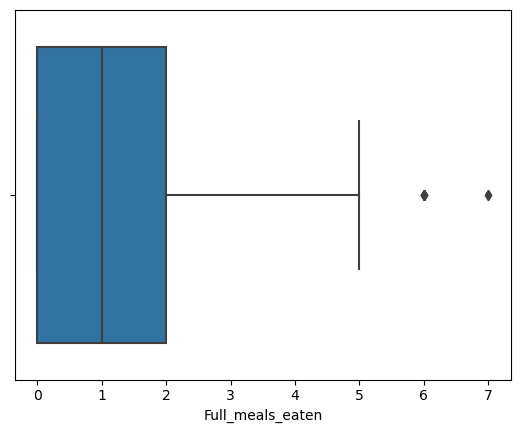

In [189]:
#Checking for outliers for Full meals eaten
sns.boxplot(x = 'Full_meals_eaten', data = df)

<Axes: xlabel='vitD_supp'>

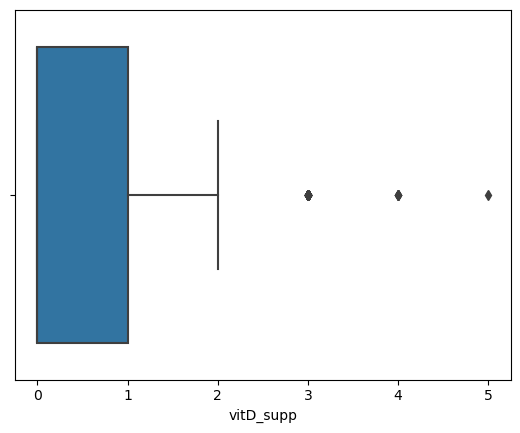

In [190]:
#Checking for outliers for Vitamin D supplement
sns.boxplot(x = 'vitD_supp', data = df)

In [191]:
#Feature scaling for numerical columns, excluding the target variable 'ReAdmis'
scaler = StandardScaler()
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.difference(['ReAdmis'])
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [192]:
#Split the Data into Features (X) and Target (y)
X = df.drop(columns=['ReAdmis'])
y = df['ReAdmis']

In [193]:
#Split the Data into Training and Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [194]:
#Save training and testing data to CSV files
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

In [195]:
#Load the saved files to check if they were saved correctly
X_train_loaded = pd.read_csv("X_train.csv")
X_test_loaded = pd.read_csv("X_test.csv")
y_train_loaded = pd.read_csv("y_train.csv")
y_test_loaded = pd.read_csv("y_test.csv")

In [196]:
#The KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

#Prediction
y_pred_proba= knn_model.predict_proba(X_test)[:,1]
y_pred = (y_pred_proba > 0.5).astype(int)

In [197]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.578


In [198]:
#Confusion Matrix
conf_matrix_knn = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix: \n{conf_matrix_knn}")

Confusion Matrix: 
[[1428  506]
 [ 760  306]]


In [199]:
#AUC (Area Under the Curve)
auc_knn = roc_auc_score(y_test, y_pred)
print(f"AUC: {auc_knn}")

AUC: 0.5127102448337346


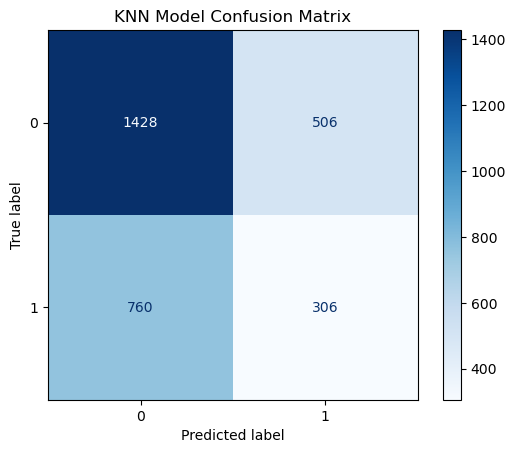

In [200]:
#Visualizing the Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_knn)
disp.plot(cmap=plt.cm.Blues)
plt.title('KNN Model Confusion Matrix')
plt.show()

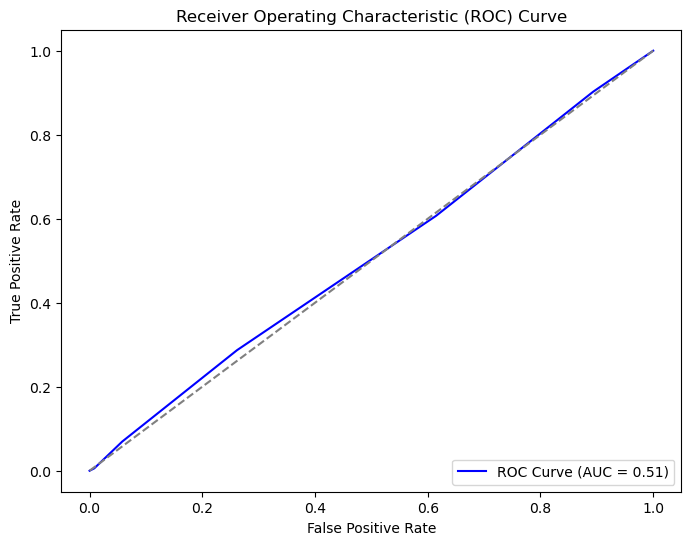

In [201]:
#ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', label='ROC Curve (AUC = %0.2f)' % auc_knn)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [202]:
#Save cleaned dataset
new_data_path = 'output/new_medical_data_D209_I.csv'
df.to_csv(new_data_path, index=False)